# BC vs CQL — offline policy comparison (answering Max's Q1)

**Question:** *"the differences in the policy after the offline phase between the CQL and BC — to
understand the performance gap between the two."*

Both are the **offline-trained CIRL policies** (state → PI gains), evaluated **zero-shot on Juan's
4 new days** (the setting where the online experiments run). They live in different gain boxes:

- **BC** (`bc_cirl_setpoint_anti_windup_best.pt`): outputs `[Kp, Ki, Kd]`, anti-windup `Kw = Ki/Kp`.
- **CQL** (`cql_cirl_actor_best.pt`): outputs `[Kp, Ki, Kw]` (learns the anti-windup gain too).

Each is rolled out with its own control law; the resulting closed-loop tracking is directly comparable.


In [1]:
# ── Setup: shared library + config ───────────────────────────────────────────
import os, sys
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import torch
sys.path.insert(0, os.getcwd())
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), os.pardir)))  # main_script
from main_script import *
import config as cfg
from config import *
configure(cfg)

# The two offline policies + their gain boxes
BC_CKPT   = 'bc_cirl_setpoint_anti_windup_best.pt'
CQL_CKPT  = 'cql_cirl_actor_best.pt'
BC_LOW    = np.array([-0.625, -0.625/300, 0.0], np.float32)   # [Kp,Ki,Kd]
BC_HIGH   = np.array([-0.375, -0.125/300, 0.0], np.float32)
CQL_LOW   = np.array([-3.5,  -0.060, -0.35], np.float32)      # [Kp,Ki,Kw]
CQL_HIGH  = np.array([-0.1,  -0.0002, 0.05], np.float32)

def load_policy(ckpt):
    a = GainActor(in_dim=9, out_dim=3).to(DEVICE)
    a.load_state_dict(torch.load(os.path.join(SAVE_DIR, ckpt), map_location=DEVICE, weights_only=True))
    a.eval(); return a

bc_pol, cql_pol = load_policy(BC_CKPT), load_policy(CQL_CKPT)

def rollout_gains(actor, data, glow, ghigh, mode):
    """Roll a gain policy; mode='pid_kd' (BC) or 'pid_kw' (CQL). Returns tracking + applied gains."""
    tref = dataset_tref(data['name'])
    Tin=data['Tin']; I=data['I_sol']; Ta=data['Ta']; th=data['theta']; T_sc=data['T_sc']; qm=data['q']; N=data['N']
    tout=float(T_sc[0]); tout_prev=tout; q_prev=float(qm[0]); int_e=None
    T=[];Q=[];Kp_l=[];Ki_l=[];Kw_l=[]
    with torch.no_grad():
        for t in range(N-1):
            e=tref-tout; de=-(tout-tout_prev)/TS
            ie = 0.0 if int_e is None else int_e
            state=np.array([tout,e,ie,de,I[t],Ta[t],Tin[t],th[t],tref],np.float32)
            s=torch.from_numpy(normalize_obs(state).reshape(1,-1))
            g=np.clip(actor(s).cpu().numpy()[0],0,1)*(ghigh-glow+1e-8)+glow
            Kp,Ki,g3=g
            if int_e is None:   # bumpless preload with the POLICY's own gains (matches SolarFieldEnv)
                int_e=float(np.clip((q_prev - Kp*e)/Ki, -INT_E_CLIP, INT_E_CLIP))
            if mode=='pid_kd':
                q_raw=Kp*e+Ki*int_e+g3*de; Kw=Ki/Kp
            else:
                q_raw=Kp*e+Ki*int_e; Kw=g3
            q=float(np.clip(q_raw,Q_MIN,Q_MAX))
            tn=solar_model(q,Tin[t],I[t],Ta[t],th[t],tout)
            T.append(tn);Q.append(q);Kp_l.append(Kp);Ki_l.append(Ki);Kw_l.append(Kw)
            int_e=float(np.clip(int_e+(e+Kw*(q-q_raw))*TS,-INT_E_CLIP,INT_E_CLIP))
            tout_prev=tout; tout=tn; q_prev=q
    return dict(Tout=np.array(T),q=np.array(Q),Kp=np.array(Kp_l),Ki=np.array(Ki_l),Kw=np.array(Kw_l))

datasets=[load_dataset(f) for f in JUAN_FILES]
print("Loaded BC + CQL offline policies; evaluating on", len(datasets), "Juan days.")


Loaded BC + CQL offline policies; evaluating on 4 Juan days.


In [2]:
# ── 1. Closed-loop accuracy on Juan's days (Expert vs BC vs CQL) ─────────────
rows=[]
store={'Expert':[], 'BC':[], 'CQL':[]}
for ds in datasets:
    tr=dataset_tref(ds['name'])
    Te,_=rollout_expert(ds)
    rb=rollout_gains(bc_pol, ds, BC_LOW, BC_HIGH, 'pid_kd')
    rc=rollout_gains(cql_pol, ds, CQL_LOW, CQL_HIGH, 'pid_kw')
    store['Expert'].append(dict(Tout=Te)); store['BC'].append(rb); store['CQL'].append(rc)
    for name,T in [('Expert',Te),('BC',rb['Tout']),('CQL',rc['Tout'])]:
        m,rm=mae_rmse(T,tr); rows.append((ds['name'][:11],name,m,rm,peak_overshoot(T,tr)))

import collections
agg=collections.defaultdict(lambda:[[],[],[]])
print(f"{'controller':10s} {'MAE':>7} {'RMSE':>7} {'overshoot':>10}")
print('-'*40)
for name in ['Expert','BC','CQL']:
    sub=[r for r in rows if r[1]==name]
    mae=np.mean([r[2] for r in sub]); rmse=np.mean([r[3] for r in sub]); ov=np.mean([r[4] for r in sub])
    print(f"{name:10s} {mae:7.3f} {rmse:7.3f} {ov:10.3f}")
print("\n(mean over Juan's 4 days; each policy in its own gain box.)")


controller     MAE    RMSE  overshoot
----------------------------------------
Expert       1.224   1.731      5.924
BC           1.224   1.731      5.925
CQL          0.243   0.501      3.674

(mean over Juan's 4 days; each policy in its own gain box.)


In [3]:
# ── 2. What gains does each policy apply?  (mean +/- std over all steps) ─────
def gstats(key):
    allv=np.concatenate([store['BC'][i][key] for i in range(len(datasets))])
    allc=np.concatenate([store['CQL'][i][key] for i in range(len(datasets))])
    return allv, allc

print(f"{'gain':6s} {'Expert':>10} {'BC (mean±std)':>22} {'CQL (mean±std)':>22}")
print('-'*62)
exp={'Kp':KP_EXPERT,'Ki':KI_EXPERT,'Kw':KI_EXPERT/KP_EXPERT}
for k in ['Kp','Ki','Kw']:
    b,c=gstats(k)
    print(f"{k:6s} {exp[k]:>10.5f} {np.mean(b):>10.5f}±{np.std(b):<10.5f} {np.mean(c):>10.5f}±{np.std(c):<10.5f}")
print("\nstd over time = how state-adaptive the policy is (Expert = 0, constant).")


gain       Expert          BC (mean±std)         CQL (mean±std)
--------------------------------------------------------------
Kp       -0.50000   -0.49976±0.00001      -1.84243±0.01660   
Ki       -0.00167   -0.00167±0.00000      -0.04511±0.00061   
Kw        0.00333    0.00333±0.00000      -0.16221±0.00292   

std over time = how state-adaptive the policy is (Expert = 0, constant).


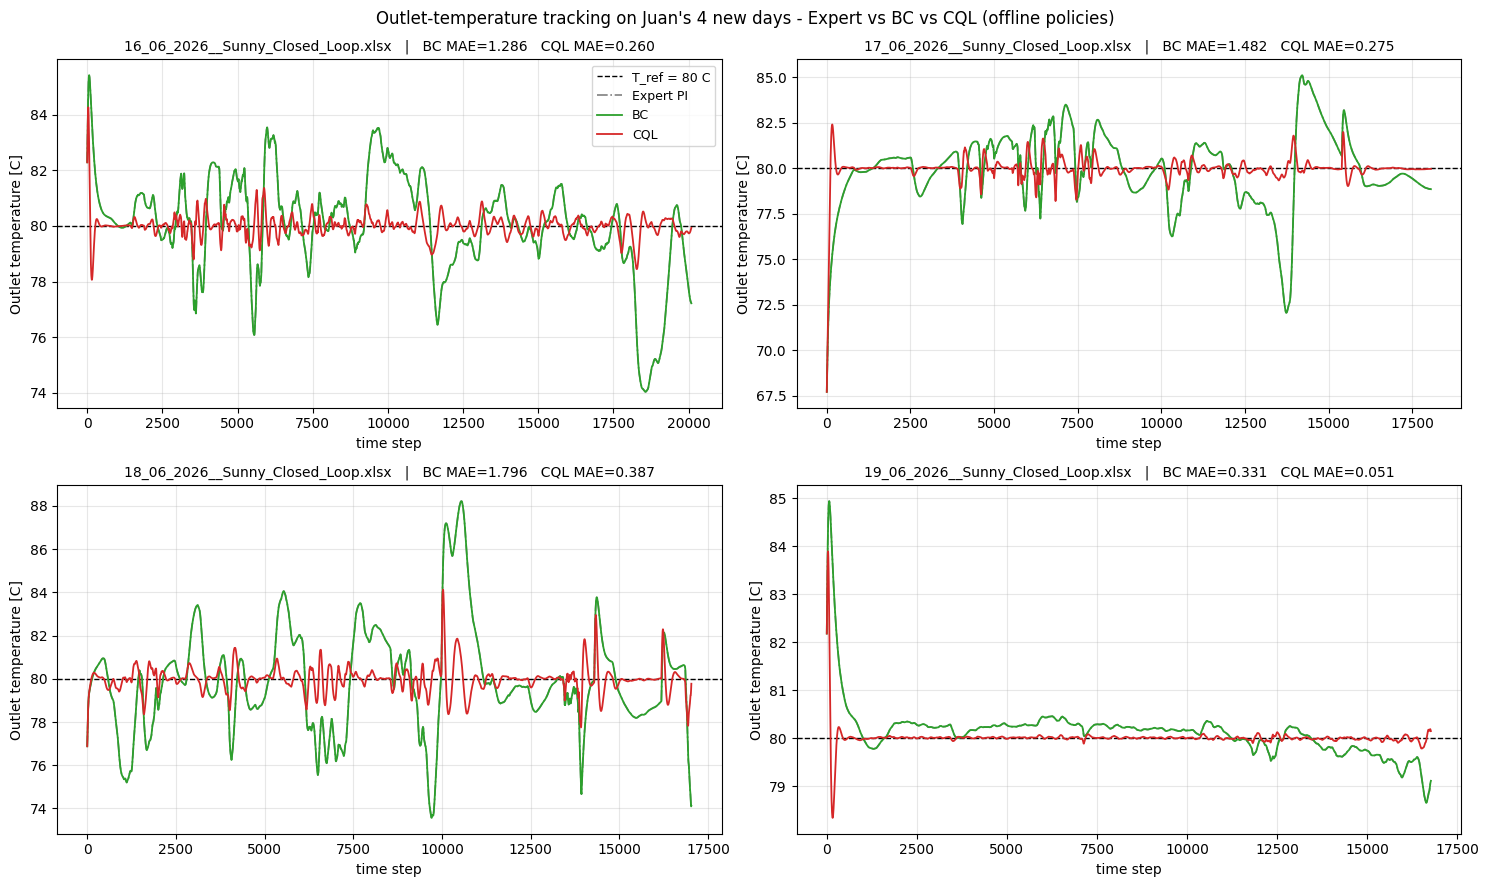

In [4]:
# ── Outlet-temperature tracking on all 4 Juan days (Expert / BC / CQL) ───────
fig, axes = plt.subplots(2, 2, figsize=(15, 9))
for i, ds in enumerate(datasets):
    ax = axes[i // 2, i % 2]
    tr = dataset_tref(ds["name"])
    Te = store["Expert"][i]["Tout"]; Tb = store["BC"][i]["Tout"]; Tc = store["CQL"][i]["Tout"]
    t = np.arange(len(Tb))
    ax.axhline(tr, ls="--", c="k", lw=1, label=f"T_ref = {tr:.0f} C")
    ax.plot(t, Te[:len(t)], c="gray",    ls="-.", lw=1.2, label="Expert PI")
    ax.plot(t, Tb,          c="#2ca02c", lw=1.3,  label="BC")
    ax.plot(t, Tc,          c="#d62728", lw=1.3,  label="CQL")
    mb = mae_rmse(Tb, tr)[0]; mc = mae_rmse(Tc, tr)[0]
    ax.set_title(f"{ds['name']}   |   BC MAE={mb:.3f}   CQL MAE={mc:.3f}", fontsize=10)
    ax.set_ylabel("Outlet temperature [C]"); ax.set_xlabel("time step"); ax.grid(alpha=.3)
    if i == 0:
        ax.legend(fontsize=9)
fig.suptitle("Outlet-temperature tracking on Juan's 4 new days - Expert vs BC vs CQL (offline policies)", fontsize=12)
fig.tight_layout()
fig.savefig(os.path.join(CHART_DIR, "offline_bc_vs_cql_tracking_4days.png"), dpi=150)
plt.show()


## What this shows (summary for Max)

- **BC clones the expert.** Its imitation-dominant loss pins `Kp, Ki` close to the fixed expert gains
  with little state-dependence, so BC's closed-loop tracking ≈ the Expert PI.
- **CQL departs from the expert.** The conservative value function pushes `Kp, Ki` to stronger,
  more state-adaptive values (and learns a distinct `Kw`), producing tighter tracking on the new days.

**That is the performance gap:** BC can only be as good as the demonstrator it copies, whereas CQL,
optimising a (conservative) return, discovers a better-than-expert controller — which is why the
CQL policy transfers to Juan's data far better out-of-the-box and needs less online refinement.

The two figures above (gains-over-time + distributions, and the accuracy table) quantify this.
